In [ ]:
import numpy as np
import keras
from keras import layers
import tensorflow as tfds
import matplotlib.pyplot as plt
import os

from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ruta al dataset
pathDataset = "./dataset"

# Contar número de clases
numClasses = len(os.listdir(pathDataset + "/train"))
print("Numero de clases: " + str(numClasses))

# Generadores de datos
trainValDataMod = ImageDataGenerator(validation_split=0.25)
testDataMod = ImageDataGenerator()

# Datos de entrenamiento
trainData = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Datos de validación
valData = trainValDataMod.flow_from_directory(
    directory=pathDataset + "/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

# Datos de prueba
testData = testDataMod.flow_from_directory(
    directory=pathDataset + "/test",
    target_size=(150, 150),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


base_model = keras.applications.InceptionV3(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(150, 150, 3),
    include_top=False,
)  # Do not include the ImageNet classifier at the top.

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(150, 150, 3))

scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)
x = scale_layer(inputs)

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)  # Regularize with dropout
outputs = keras.layers.Dense(13)(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable=True)

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()],
)

epochs = 30

bestModel = "./bestModel.keras"
os.makedirs(os.path.dirname(bestModel), exist_ok=True)
callbacks = [
    ModelCheckpoint(bestModel, verbose=1, save_best_only=True, monitor="val_accuracy"),
    ReduceLROnPlateau(monitor="val_accuracy", patience=4, factor=0.1, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1)
]


print("Fitting the top layer of the model")
model.fit(trainData, epochs=epochs, validation_data=valData, callbacks = callbacks)



base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # Low learning rate
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy()],
)

epochs = 15
print("Fitting the end-to-end model")
history = model.fit(trainData, epochs=epochs, validation_data=valData, callbacks = callbacks)

print("Test dataset evaluation")
test_loss, test_accuracy = model.evaluate(testData, verbose=0)

# Graficar comparación final entre train/val/test
def plotFinalAccuracies(history, test_acc):
    train_acc = history.history["binary_accuracy"][-1]
    val_acc = history.history["val_binary_accuracy"][-1]

    labels = ["Entrenamiento", "Validación", "Test"]
    values = [train_acc, val_acc, test_acc]

    plt.bar(labels, values, color=["skyblue", "orange", "lightgreen"])
    plt.title("Accuracy final por conjunto")
    plt.ylim(0, 1)
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.ylabel("Accuracy")
    plt.show()

plotFinalAccuracies(history, test_accuracy)




Numero de clases: 13
Found 1624 images belonging to 13 classes.
Found 535 images belonging to 13 classes.
Found 86 images belonging to 13 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 150, 150, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ inception_v3 (Functional)   │ (None, 3, 3, 2048)    │ 21,802,784 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 13)            │     26,637 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21,829,421 (83.27 MB)

 Trainable params: 26,637 (104.05 KB)

...

 Trainable params: 21,794,989 (83.14 MB)

 Non-trainable params: 34,432 (134.50 KB)

 Optimizer params: 53,276 (208.11 KB)

Fitting the end-to-end model
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - binary_accuracy: 0.9333 - loss: 0.2737 - val_binary_accuracy: 0.9714 - val_loss: 0.0735 - learning_rate: 1.0000e-05
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - binary_accuracy: 0.9785 - loss: 0.1284 - val_binary_accuracy: 0.9567 - val_loss: 0.1065 - learning_rate: 1.0000e-05
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - binary_accuracy: 0.9820 - loss: 0.0967 - val_binary_accuracy: 0.9708 - val_loss: 0.0930 - learning_rate: 1.0000e-05
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - binary_accuracy: 0.9848 - loss: 0.0725 - val_binary_accuracy: 0.9797 - val_loss: 0.0835 - learning_rate: 1.0000e-05
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - binary_accuracy: 0.9858 - loss: 0.0613 - val_binary_accuracy: 0.9815 - val_loss: 0.0775 - learning_rate: 1.0000e-05
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Test dataset evaluation


KeyError: 'accuracy'

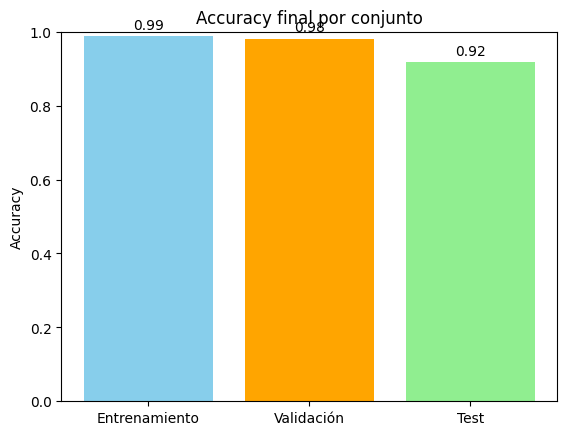